## notebook for waelet coherence

In [1]:
import numpy as np
import xarray as xr
import os

import pycwt #  as wavelet
# from pycwt.helpers import find

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import cmocean as cmo
import palettable.colorbrewer as cb 

from process_raw_data import process_data, decimal_year_to_datetime 
from stats_plots import plot_timeseries

In [2]:
SAVING = True 
ds = xr.open_dataset("data/Bayesian_estimates_Atlantic_MHT_HTC_HF_OHC.nc")
ds["time"] = decimal_year_to_datetime(ds.time.values)

mht = ds.mht.isel(lat=slice(1,None)).dropna(dim="time", how="any") # drop 65

mht_mean = mht.mean(dim="posterior_samples")

# detrend , mean removed
mht_detrended_anom = process_data(mht_mean, detrended=True).dropna(dim="time", how="any")

# pycwt already accounts for mean and std!
# mht_std = mht_detrended_anom.std(dim="time")
# mht_norm = mht_detrended_anom / mht_std

## check normality

In [3]:
# lat_idx = 1
# data = mht_mean.isel(lat=lat_idx).to_numpy()

# plt.hist(data, bins=15, color="steelblue", edgecolor="white")
# plt.title(f"Histogram at lat index {lat_idx}")
# plt.xlabel("MHT")
# plt.ylabel("Count")
# plt.show()

In [4]:
lats = ds.latitude.values
lat_labels = [f"{np.abs(lat)}{'°N' if lat > 0 else '°S'}" for lat in lats]

lats = lats[1:]  # drop 65
lat_labels = lat_labels[1:]  # drop 65
n_lats = len(lats)


In [5]:
plt.rcParams.update({
    # axes
    'axes.titlesize'  : 18,
    'axes.labelsize'  : 18,
    # ticks
    'xtick.labelsize' : 15,
    'ytick.labelsize' : 15,
    # legend
    'legend.fontsize' : 14,
    'legend.title_fontsize': 14,
    # colorbar
    'figure.titlesize': 20,
})

In [6]:
# cmap_sel = plt.cm.Greens

# cmap = mcolors.ListedColormap(cmap_sel(np.linspace(0.5, 1, 40)))

# plot_timeseries(
#     data={
#         # "raw": mht_mean,
#         # "detrended anom":  mht_detrended_anom,
#         "normalized ( / std per lat)": mht_norm,
#     },
#     lats=[-5.0],
#     all_lats=lats,
#     labels=lat_labels,
#     cmap=cmap,
#     anomalies=False,
#     xbase=4,
#     ylabel="MHT (std normalized)"
# )

## latitude pairs: 16°N - 5°N , where break happens

In [7]:
idx_5 = [np.where((lats == 5))[0][0]]
idx_5S = [np.where((lats == -5))[0][0]]
idx_16 = [np.where((lats == 16))[0][0]]
mht_5_pd = mht_detrended_anom.isel(lat=idx_5).to_numpy()[0]
mht_5S_pd = mht_detrended_anom.isel(lat=idx_5S).to_numpy()[0]
mht_16_pd = mht_detrended_anom.isel(lat=idx_16).to_numpy()[0]

## latitude pairs 26°N and 11°S, in the middle of each block

In [8]:
idx_26 = [np.where((lats == 26))[0][0]]
idx_11S = [np.where((lats == -11))[0][0]]
idx_25S = [np.where((lats == -25))[0][0]]
mht_26_pd = mht_detrended_anom.isel(lat=idx_26).to_numpy()[0]
mht_11S_pd = mht_detrended_anom.isel(lat=idx_11S).to_numpy()[0]
mht_25S_pd = mht_detrended_anom.isel(lat=idx_25S).to_numpy()[0]


time = mht.time.values

In [108]:
def wct_analysis(
    y1, y2, 
    time, 
    sig=True, 
    normalize=True,
    ):
    
    N = len(time) # all have the same time
    dt = 0.25
    s0 = 2 * dt
    dj = 1 / 10

    J = int(1/dj * np.log2(N * dt / s0)) 
    
    WCT, arrowsWCT, COI, freq, sig, W1, W2 = pycwt.wct(
        y1=y1,
        y2=y2,
        dt=dt,
        dj=dj,
        s0=s0,
        J=J,
        sig=sig,
        normalize=normalize, # default : true, normalized with STD!
        cache=False
    )
    
    period = 1 / freq

    return WCT, arrowsWCT, COI, period, sig
    
    
def wct_plot(
    WCT, arrowsWCT, COI, period, sig,
    time, 
    cmap=cb.sequential.YlGnBu_9.mpl_colormap,
    vmin=0,
    vmax=1,
    title="26°N and 11°S",
    analysis_type="Coherence", # can be coherence or power ( for individual CWT plot)
    savefig=False,
    savelabel="cwt_26_11S",
    ):
        
    fig, ax  = plt.subplots(figsize=(8.5, 6))

    if vmin is not None and vmax is not None:
        cf = ax.pcolormesh(time, period, WCT, cmap=cmap, shading='auto', vmin=vmin, vmax=vmax)
    else:
        cf = ax.pcolormesh(time, period, WCT, cmap=cmap, shading='auto')

    fig.colorbar(cf, label=analysis_type)

    ax.plot(time, COI, 'k--', linewidth=1.5, label="COI")
    ax.fill_between(time, COI, period.max(), color='white', alpha=0.6, zorder=5)

    # significance contour (sig=1 marks 95% significance boundary)
    # 
    if sig is not None:
        sig_2d = np.ones_like(WCT) * sig[:, np.newaxis]  # broadcast to (scales, time)
        # shading the NOT significant part:
        sig_ratio = WCT / sig_2d
        # Shade non-significant regions (ratio < 1) 
        sig_shading = ax.contourf(time, period, sig_ratio, levels=[0, 1], colors='None', hatches=['//'], label="Region of no significance")
        sig_shading.set_edgecolor('white')
        sig_shading.set_linewidth(0)
            
        # ax.contourf(time, period, sig_ratio, levels=[0, 1], colors='white', alpha=0.4)
        ax.contour(time, period, sig_ratio, [1], colors='white', linewidths=1.5, label="Sig. 95% (AR(1))")
    
    # phase arrows (subsample so arrows aren't too dense)
    skip_t = 3
    skip_p = 3
    # sliciing the time and period and arrows , ::step
    # quiver doesnt take angle directly but x and y direction
    # x = cos(angle), y ( sin(angle) )
    if arrowsWCT is not None:
        ax.quiver(time[::skip_t], period[::skip_p],
                np.cos(arrowsWCT)[::skip_p, ::skip_t], np.sin(arrowsWCT)[::skip_p, ::skip_t],
                scale=30, width=0.003)

    ax.set_yscale('log', base=2)
    # change ticks to be not 2^0 but 1
    yticks = 2 ** np.arange(np.floor(np.log2(period.min())), np.ceil(np.log2(period.max())))
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{int(y)}' if y >= 1 else f'{y:.1f}' for y in yticks])
    ax.yaxis.set_minor_locator(plt.NullLocator())  # removes minor tick clutter

    ax.set_ylim(float(0.5), float(8.0))
    
    ax.invert_yaxis()  # short periods on top, like the book figure

    
    ax.xaxis.set_major_locator(mdates.YearLocator(base=2))        # tick only at each year
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # show only the year number
        
    ax.set_xlabel('Time')
    ax.set_ylabel('Period (years)')
    ax.set_title(f"{title}")
    
    ## handles for the legend
    if arrowsWCT is not None and sig is not None:
        legend_elements = [
            Line2D([0], [0], color='gray', linestyle='--', linewidth=1.5, label='Cone of influence'),
            Patch(facecolor='none', edgecolor='gray', hatch='//', label='Not significant (95%)'),
            # Line2D([0], [0], color='gray', linewidth=1.5, label='Sig. 95%'),
            Line2D([0], [0], color='black', linestyle="None", marker=r"$\longrightarrow$", markersize=15, label='Phase'),
        ]
    if arrowsWCT is None:
        legend_elements = [
            Line2D([0], [0], color='gray', linestyle='--', linewidth=1.5, label='Cone of influence'),
        ]

    legend = ax.legend(
        handles=legend_elements,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.24),
        ncol=4,
        frameon=True,
        fontsize=14,
        # facecolor="gray",
        # edgec olor="black",
    )
    # for text in legend.get_texts():
    #     text.set_color('white')
    
    # plt.grid("grey", linestyle="--", alpha=0.5)

    if savefig:
        os.makedirs("figures/wct/", exist_ok=True)
        plt.savefig(f"figures/wct/{savelabel}.png", dpi=300, bbox_inches='tight')
    plt.show()
    

## plotting CWT with timeseries option:

In [109]:
def cwt_plot(
    power, COI, period,
    time,
    timeseries,
    cmap=cb.sequential.YlGnBu_9.mpl_colormap,
    vmin=None,
    vmax=None,
    title="16°N CWT",
    analysis_type="Power",
    timeseries_label="Index",
    savefig=False,
    savelabel="cwt_plot",
):
    fig = plt.figure(figsize=(7.5, 7.5))
    gs = fig.add_gridspec(
        nrows=2, ncols=2,
        width_ratios=[30, 1],     # main plot vs colorbar column
        height_ratios=[3, 1],     # wavelet panel taller than timeseries panel
        hspace=0.15,              # whitespace between the two panels
        wspace=0.04,
    )
    ax = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])
    ax_ts = fig.add_subplot(gs[1, 0], sharex=ax)

    if vmin is not None and vmax is not None:
        cf = ax.pcolormesh(time, period, power, cmap=cmap, shading='auto', vmin=vmin, vmax=vmax)
    else:
        cf = ax.pcolormesh(time, period, power, cmap=cmap, shading='auto')

    fig.colorbar(cf, cax=cax, label=analysis_type)

    ax.plot(time, COI, 'k--', linewidth=1.5, label="COI")
    ax.fill_between(time, COI, period.max(), color='white', alpha=0.6, zorder=5)

    ax.set_yscale('log', base=2)
    yticks = 2 ** np.arange(np.floor(np.log2(period.min())), np.ceil(np.log2(period.max())))
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{int(y)}' if y >= 1 else f'{y:.1f}' for y in yticks])
    ax.yaxis.set_minor_locator(plt.NullLocator())

    ax.set_ylim(float(0.5), float(8.0))
    ax.invert_yaxis()

    ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_ylabel('Period (years)')
    ax.set_title(f"{title}")

    plt.setp(ax.get_xticklabels(), visible=False)  # top panel: no x labels, bottom panel carries them
    ax.set_xlabel("")

    legend_elements = [
        Line2D([0], [0], color='gray', linestyle='--', linewidth=1.5, label='Cone of influence'),
    ]

    ax.legend(
        handles=legend_elements,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.28),
        ncol=len(legend_elements),
        frameon=True,
        fontsize=14,
    )

    # timeseries subfigure ( following idea from :A. Grinsted1, J. C. Moore1, and S. Jevrejeva2 2004) 
    
    ax_ts.plot(time, timeseries, 'k-', linewidth=1)
    ax_ts.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    ax_ts.set_ylabel(timeseries_label)
    ax_ts.set_xlabel('Time')
    # ax_ts.set_ylim(-0.53, 0.53)
    ax_ts.xaxis.set_major_locator(mdates.YearLocator(base=2))
    ax_ts.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    if savefig:
        os.makedirs("figures/wct/", exist_ok=True)
        plt.savefig(f"figures/wct/{savelabel}.png", dpi=300, bbox_inches='tight')
    plt.show()

## first compute WCT for all pairs, just run once, takes some time, then do analysis = False and plot

## 26°N and 11°S

Calculating wavelet coherence significance


100%|██████████| 300/300 [00:10<00:00, 28.69it/s]
/var/folders/8k/45q47bzd1bxgf8pbps6hbstr0000gn/T/ipykernel_4096/3548687581.py:63: UserWarning: The following kwargs were not used by contour: 'label'
  sig_shading = ax.contourf(time, period, sig_ratio, levels=[0, 1], colors='None', hatches=['//'], label="Region of no significance")
/var/folders/8k/45q47bzd1bxgf8pbps6hbstr0000gn/T/ipykernel_4096/3548687581.py:68: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(time, period, sig_ratio, [1], colors='white', linewidths=1.5, label="Sig. 95% (AR(1))")


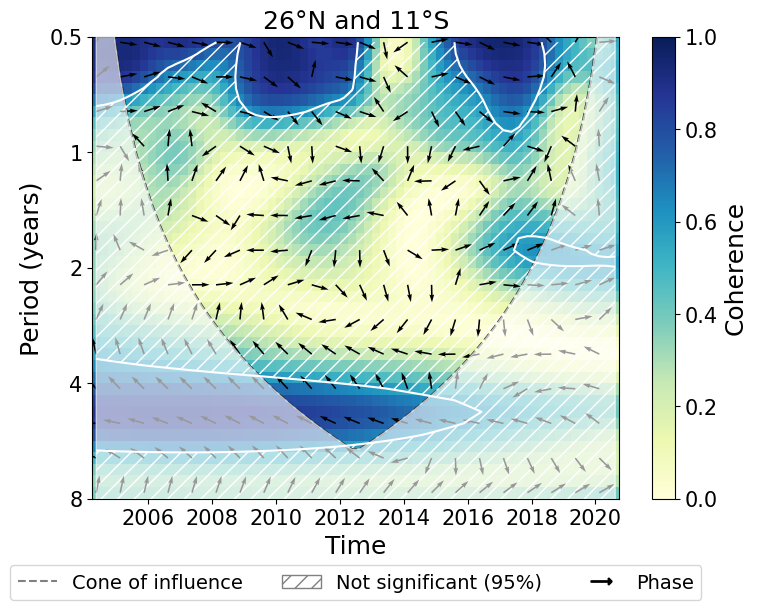

In [110]:
do_analysis = True
if do_analysis:
    WCT, arrowsWCT, COI, period, sig = wct_analysis(
        mht_26_pd,
        mht_11S_pd,
        time=time
    )

cmap = cb.sequential.YlGnBu_9.mpl_colormap
# cmap = "viridis"
wct_plot(
   WCT, arrowsWCT, COI, period, sig,
   time=time,
   cmap=cmap,
   savefig=True,
   savelabel="26_11S"
#    title="" 
)


## 26°N and 25°S

In [111]:
# if do_analysis:
#     WCT_2625S, arrowsWCT_2625S, COI_2625S, period_2625S, sig_2625S = wct_analysis(
#         mht_26_pd,
#         mht_25S_pd,
#         time=time
#     )
    
# wct_plot(
#     WCT_2625S, arrowsWCT_2625S, COI_2625S, period_2625S, sig_2625S,
#     time=time,
#     cmap=cmap,
#     title="26°N and 25°S",
#     savefig=True,
#     savelabel="26_25S"
# )

## 16°N and 5°N

Calculating wavelet coherence significance


100%|██████████| 300/300 [00:10<00:00, 27.95it/s]
/var/folders/8k/45q47bzd1bxgf8pbps6hbstr0000gn/T/ipykernel_4096/3548687581.py:63: UserWarning: The following kwargs were not used by contour: 'label'
  sig_shading = ax.contourf(time, period, sig_ratio, levels=[0, 1], colors='None', hatches=['//'], label="Region of no significance")
/var/folders/8k/45q47bzd1bxgf8pbps6hbstr0000gn/T/ipykernel_4096/3548687581.py:68: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(time, period, sig_ratio, [1], colors='white', linewidths=1.5, label="Sig. 95% (AR(1))")


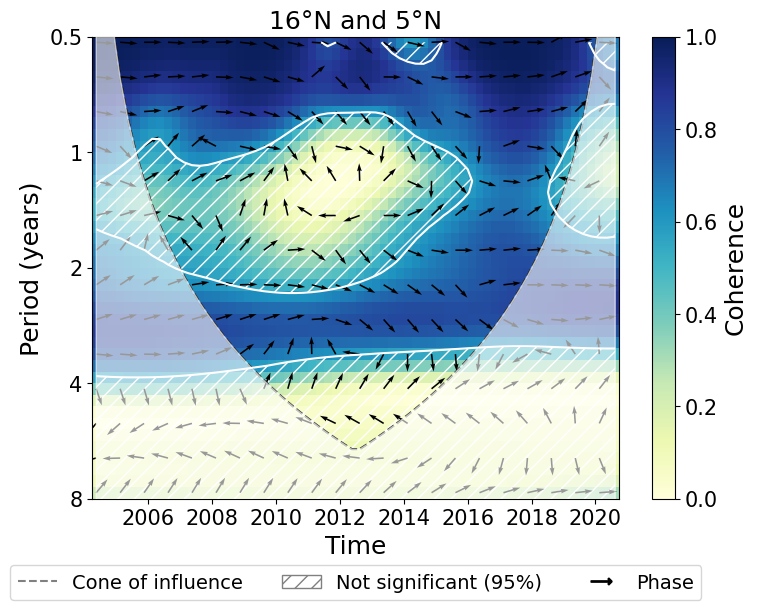

In [112]:
if do_analysis:
    WCT_165, arrowsWCT_165, COI__165, period_165, sig_165 = wct_analysis(
        mht_16_pd,
        mht_5_pd,
        time=time
    )
    
wct_plot(
    WCT_165, arrowsWCT_165, COI__165, period_165, sig_165,
    time=time,
    cmap=cmap,
    title="16°N and 5°N",
    savefig=True,
    savelabel="16_5N"
)

## get also individual wavetransform for 16 and 5

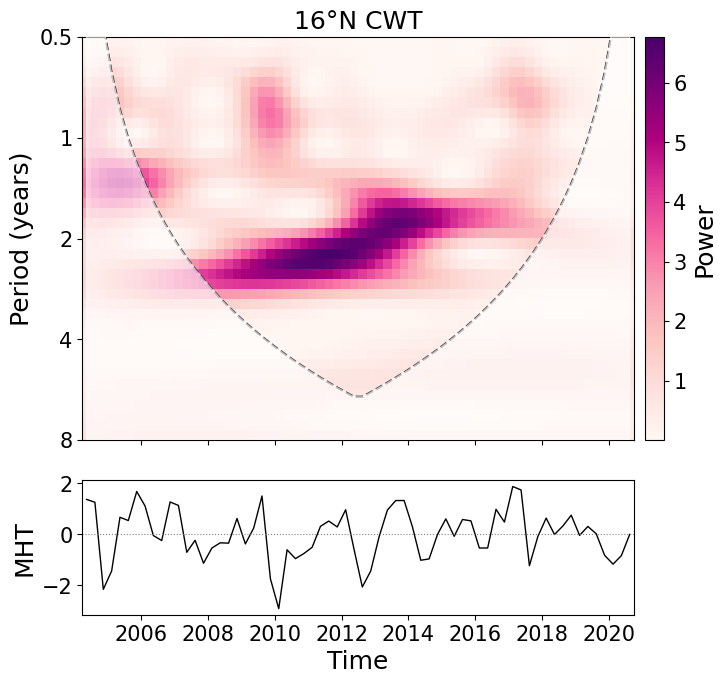

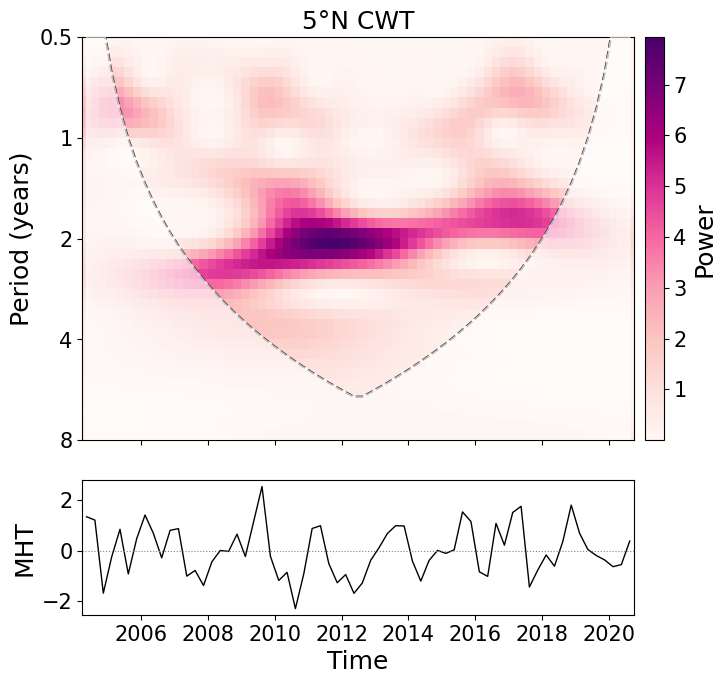

In [107]:
y1 = mht_16_pd
y2 = mht_5_pd
wavelet="morlet"
N = len(time) # all have the same time
dt = 0.25
s0 = 2 * dt
dj = 1 / 10

J = int(1/dj * np.log2(N * dt / s0)) 
    
# Makes sure input signals are numpy arrays.
y1 = np.asarray(y1)
y2 = np.asarray(y2)
# Calculates the standard deviation of both input signals.
std1 = y1.std()
std2 = y2.std()
# Normalizes both signals, if appropriate.
y1_normal = (y1 - y1.mean()) / std1
y2_normal = (y2 - y2.mean()) / std2

# Calculates the CWT of the time-series making sure the same parameters
# are used in both calculations.
_kwargs = dict(dj=dj, s0=s0, J=J, wavelet=wavelet)
W1, sj_1, freq_1, coi_1, _, _ = pycwt.cwt(y1_normal, dt, **_kwargs)
W2, sj_2, freq_2, coi_2, _, _ = pycwt.cwt(y2_normal, dt, **_kwargs)

power1 = np.abs(W1) ** 2  ## as defined in: A. Grinsted1, J. C. Moore1, and S. Jevrejeva2 2004
power2 = np.abs(W2) ** 2

cwt_plot(
    power1, coi_1, 1/freq_1,
    time=time,
    timeseries=y1_normal,       # or y1 for original (unnormalized) units
    cmap=cb.sequential.RdPu_9.mpl_colormap,
    # vmin=0,
    # vmax=8,
    title="16°N CWT",
    analysis_type="Power",
    timeseries_label="MHT",
    savefig=True,
    savelabel="cwt_16N"

)

cwt_plot(
    power2, coi_2, 1/freq_2,
    time=time,
    timeseries=y2_normal,       # or y1 for original (unnormalized) units
    cmap=cb.sequential.RdPu_9.mpl_colormap,
    # vmin=0,
    # vmax=8,
    title="5°N CWT",
    analysis_type="Power",
    timeseries_label="MHT",
    savefig=True,
    savelabel="cwt_5N"
)

## 16°N and 5°S

In [98]:
# if do_analysis:
#     WCT_165S, arrowsWCT_165S, COI_165S, period_165S, sig_165S = wct_analysis(
#         mht_16_pd,
#         mht_5S_pd,
#         time=time
#     )
    
# wct_plot(
#     WCT_165S, arrowsWCT_165S, COI_165S, period_165S, sig_165S,
#     time=time,
#     cmap=cmap,
#     title="16°N and 5°S",
#     savefig=True,
#     savelabel="16N_5S"
# )

## 35°N and 35°S

In [82]:
idx_35 = [np.where((lats == 35))[0][0]]
mht_35_pd = mht_detrended_anom.isel(lat=idx_35).to_numpy()[0]

idx_35S = [np.where((lats == -35))[0][0]]
mht_35S_pd = mht_detrended_anom.isel(lat=idx_35S).to_numpy()[0]


In [17]:
# if do_analysis:
#     WCT_35, arrowsWCT_35, COI_35, period_35, sig_35 = wct_analysis(
#         mht_35_pd,
#         mht_35S_pd,
#         time=time
#     )
    
# wct_plot(
#     WCT_35, arrowsWCT_35, COI_35, period_35, sig_35,
#     time=time,
#     cmap=cmap,
#     title="35°N and 35°S",
#     savefig=True,
#     savelabel="35S_35N"
# )